In [6]:
import pandas as pd
import numpy as np
import psycopg2
from dotenv import load_dotenv
import os
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import warnings

In [7]:
#Configuração para visualização
pd.set_option('display.float_format', lambda x: '%.4f' % x)

In [8]:
#Conexão segura com banco de dados do postgres
load_dotenv(dotenv_path="../.env")
conn = psycopg2.connect(
    host=os.getenv("DB_HOST", "localhost"),
    user=os.getenv("DB_USER"),
    password=os.getenv("DB_PASSWORD"),
    database=os.getenv("DB_NAME", "ChurnAnalysis"),
    port=os.getenv("DB_PORT", "5432")
)
cur = conn.cursor()

In [9]:
#Eliminando o warning devido ao uso do psycopg2, dado que o python recomenda o sqlalchemy
warnings.filterwarnings('ignore', category=UserWarning)

In [11]:
#Testando o acesso ao banco de dados
try:
    query = "SELECT * FROM churn;"

    # O Pandas lê direto do banco conectado
    df_churn = pd.read_sql_query(query, conn)

    print("Dados carregados com sucesso do banco ChurnAnalysis!")
    print(f"Total de linhas importadas: {len(df_churn)}")
    print(df_churn.head(3)) # Mostra as 3 primeiras linhas

except Exception as e:
    print(f"Erro ao ler os dados: {e}")

finally:
    conn.close()

Erro ao ler os dados: connection already closed


In [12]:
#Análise Exploratória dos Dados (EDA):

#Informações Gerais:
df_churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id               64374 non-null  int64 
 1   age              64374 non-null  int64 
 2   gender           64374 non-null  object
 3   tenure           64374 non-null  int64 
 4   usagesfrequency  64374 non-null  int64 
 5   suportcalls      64374 non-null  int64 
 6   paymentdelays    64374 non-null  int64 
 7   subsriptiontype  64374 non-null  object
 8   contractlength   64374 non-null  object
 9   totalspend       64374 non-null  int64 
 10  lastinteraction  64374 non-null  int64 
 11  churn            64374 non-null  int64 
dtypes: int64(9), object(3)
memory usage: 5.9+ MB


In [13]:
#Informações Gerais estatísticas:
df_churn.describe()

,id,age,tenure,usagesfrequency,suportcalls,paymentdelays,totalspend,lastinteraction,churn
count,64374.0000,64374.0000,64374.0000,64374.0000,64374.0000,64374.0000,64374.0000,64374.0000,64374.0000
mean,32187.5000,41.9710,31.9948,15.0802,5.4007,17.1340,541.0234,15.4989,0.4737
std,18583.3175,13.9249,17.0982,8.8165,3.1140,8.8522,260.8748,8.6384,0.4993
min,1.0000,18.0000,1.0000,1.0000,0.0000,0.0000,100.0000,1.0000,0.0000
25%,16094.2500,30.0000,18.0000,7.0000,3.0000,10.0000,313.0000,8.0000,0.0000
50%,32187.5000,42.0000,33.0000,15.0000,6.0000,19.0000,534.0000,15.0000,0.0000
75%,48280.7500,54.0000,47.0000,23.0000,8.0000,25.0000,768.0000,23.0000,1.0000
max,64374.0000,65.0000,60.0000,30.0000,10.0000,30.0000,1000.0000,30.0000,1.0000


In [14]:
#Informações Gerais estatísticas incluindo as variáveis categóricas :
display(df_churn.describe(include='object'))
#Top é a MODA da estatística

,gender,subsriptiontype,contractlength
count,64374,64374,64374
unique,2,3,3
top,Female,Standard,Monthly
freq,34353,21502,22130


In [18]:
#Cálculo da taxa de Churn geral
churn_counts = df_churn['churn'].value_counts()
numerador = churn_counts.get(1, churn_counts.get('SIM', churn_counts.get(True,0)))
taxa = 100 * numerador / len(df_churn)
display(taxa)

np.float64(47.368502811694164)

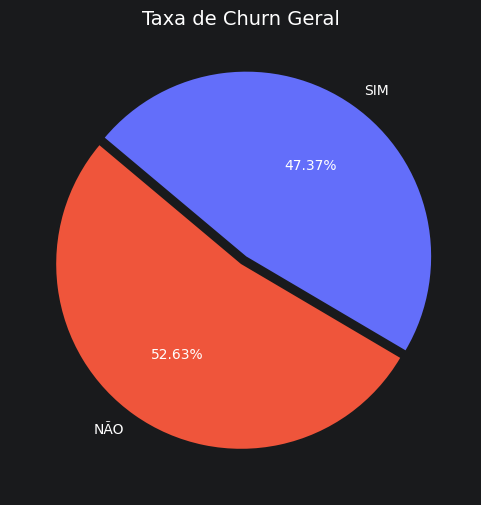

In [22]:
#Gerando um Gráfico Estático para quantificar a taxa de churn acima
churn_counts = df_churn['churn'].value_counts().rename(index= {1: 'SIM', 0: 'NÃO'}) #Conta os valores da coluna Churn
cores = ['#EF553B', '#636EFA'] #Cores do gráfico
#Criando o gráfico de pizza
plt.figure(figsize=(6, 6))
plt.pie(
    churn_counts.values,
    labels =  churn_counts.index,
    autopct = '%1.2f%%', #Duas casas decimais
    startangle = 140,
    colors = cores,
    explode = [0.05 if label == 'SIM' else 0 for label in churn_counts.index]
)
plt.title('Taxa de Churn Geral', fontsize = 14)
plt.show()

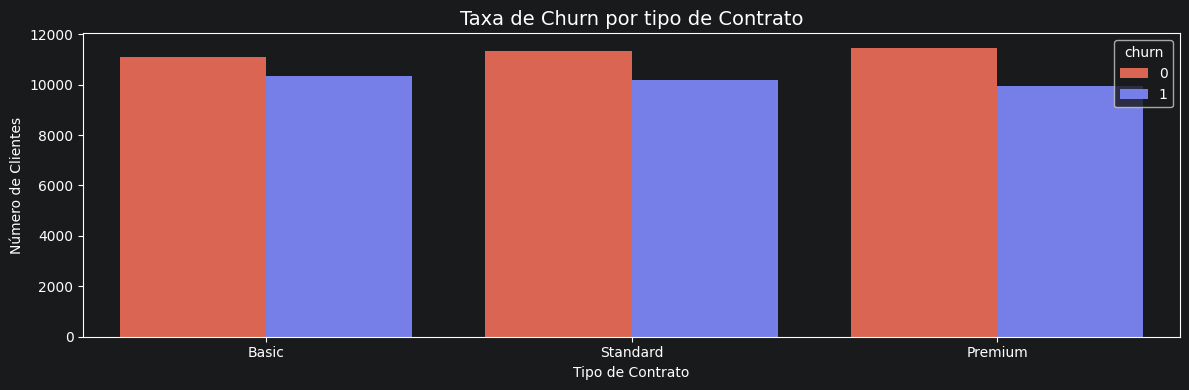

In [24]:
#gráfico de Churn por tipo de Contrato (subsriptiontype)
plt.figure(figsize=(12, 4))

sns.countplot(
    data=df_churn,
    x = 'subsriptiontype',
    hue = 'churn',
    palette = {0: '#EF553B', 1: '#636EFA'})
plt.title('Taxa de Churn por tipo de Contrato', fontsize = 14)
plt.xlabel('Tipo de Contrato')
plt.ylabel('Número de Clientes')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

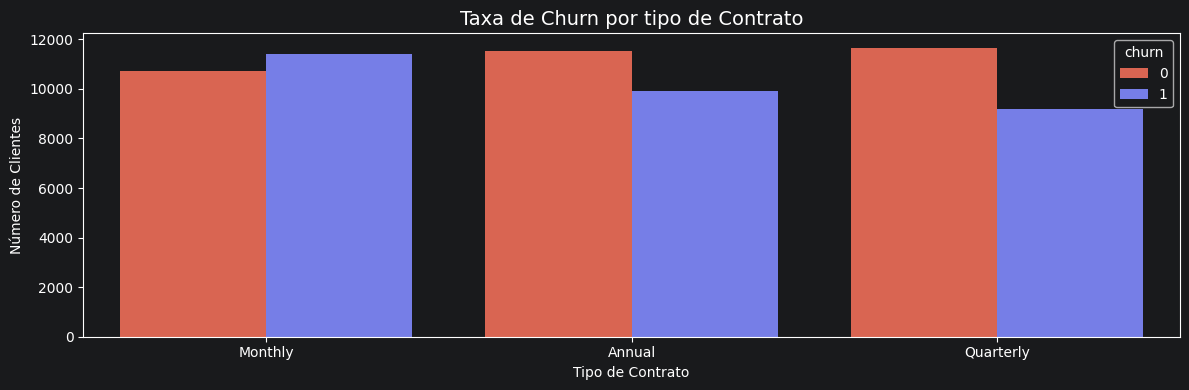

In [33]:
#gráfico de Churn por duração do Contrato (contractlength)
plt.figure(figsize=(12, 4))

sns.countplot(
    data=df_churn,
    x = 'contractlength',
    hue = 'churn',
    palette = {0: '#EF553B', 1: '#636EFA'})
plt.title('Taxa de Churn por tipo de Contrato', fontsize = 14)
plt.xlabel('Tipo de Contrato')
plt.ylabel('Número de Clientes')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [37]:
#Preparação dos Dados para modelagem estatística, utilizando One-Hot-Encoding
#Converter as variáveis categóricas em variáveis dummy (0 ou 1) e ao mesmo tempo garantir que sejam númericas
df_model = pd.get_dummies(df_churn, columns=['subsriptiontype', 'contractlength', 'gender'], drop_first=True, dtype=int)
#Criação das variáveis dummy auxilia no machine learning, pois transforma variávis categóricas em numéicas (booleanas 0 ou 1)

In [38]:
df_model.head()

,id,age,tenure,usagesfrequency,suportcalls,paymentdelays,totalspend,lastinteraction,churn,subsriptiontype_Premium,subsriptiontype_Standard,contractlength_Monthly,contractlength_Quarterly,gender_Male
0,1,22,25,14,4,27,598,9,1,0,0,1,0,0
1,2,41,28,28,7,13,584,20,0,0,1,1,0,0
2,3,47,27,10,2,29,757,21,0,1,0,0,0,1
3,4,35,9,12,5,17,232,18,0,1,0,0,1,1
4,5,53,58,24,9,2,533,18,0,0,1,0,0,0


In [39]:
#Definir as variáveis para a modelagem:
y = df_model['churn'] #Variável dependente (a que gostariamos de prever)
X = df_model.drop(['id', 'churn'], axis=1) #É ideal dropar o ID do cliente, pois a variável não tem informação instrinseca
X = sm.add_constant(X) #Adicionar a constante (intercepto). Esse passo é exigido pelo statsmodels

In [40]:
display(X.head()) #Variáveis preditoras


,const,age,tenure,usagesfrequency,suportcalls,paymentdelays,totalspend,lastinteraction,subsriptiontype_Premium,subsriptiontype_Standard,contractlength_Monthly,contractlength_Quarterly,gender_Male
0,1.0000,22,25,14,4,27,598,9,0,0,1,0,0
1,1.0000,41,28,28,7,13,584,20,0,1,1,0,0
2,1.0000,47,27,10,2,29,757,21,1,0,0,0,1
3,1.0000,35,9,12,5,17,232,18,1,0,0,1,1
4,1.0000,53,58,24,9,2,533,18,0,1,0,0,0


In [41]:
display(y.head()) #Variáveis Resposta

0    1
1    0
2    0
3    0
4    0
Name: churn, dtype: int64

In [42]:
#Modelagem Estatística:
#Rgressão logística
modelo = sm.Logit(y,X)

In [43]:
#Treinamento do Modelo
modelo_treinado = modelo.fit()

Optimization terminated successfully.
         Current function value: 0.392871
         Iterations 7


In [44]:
#Resumo do Modelo:
modelo_treinado.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                  churn   No. Observations:                64374
Model:                          Logit   Df Residuals:                    64361
Method:                           MLE   Df Model:                           12
Date:                Thu, 21 May 2026   Pseudo R-squ.:                  0.4321
Time:                        11:51:26   Log-Likelihood:                -25291.
converged:                       True   LL-Null:                       -44531.
Covariance Type:            nonrobust   LLR p-value:                     0.000
============================================================================================
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                       -5.7349      0.075    -76.543      0.000      -5.882      -5.588
age                          0.0195      0.001     24.114      0.000       0.018       0.021
tenure                       0.0354      0.001     51.663      0.000       0.034       0.037
usagesfrequency             -0.0592      0.001    -45.085      0.000      -0.062      -0.057
suportcalls                  0.3313      0.004     80.937      0.000       0.323       0.339
paymentdelays                0.2132      0.002    119.821      0.000       0.210       0.217
totalspend                  -0.0010   4.32e-05    -23.589      0.000      -0.001      -0.001
lastinteraction             -0.0010      0.001     -0.752      0.452      -0.003       0.002
subsriptiontype_Premium     -0.0949      0.027     -3.483      0.000      -0.148      -0.042
subsriptiontype_Standard    -0.0576      0.027     -2.117      0.034      -0.111      -0.004
contractlength_Monthly       0.3209      0.027     11.844      0.000       0.268       0.374
contractlength_Quarterly    -0.1741      0.027     -6.338      0.000      -0.228      -0.120
gender_Male                 -1.1363      0.023    -48.977      0.000      -1.182      -1.091
============================================================================================
"""

In [45]:
#Interpretação dos principais campos do Resultado:

#Coeficientes (coef): mostram a direção do impacto, quanto maior mais impactante. Valores negativos diminuem a chance do churn
#Valor P>z: Um valor p baixo (menor que 0.05) significa que o valor da variável é real, e não apenas coincidencia da amostra
#Pseudo R-squ: Indica a proporção da variável dependente (y) que é explicada pelo modelo

In [47]:
#Resumo de Qualidade do Modelo:
#Ajuste Sólido: O Pseudo R-squ. (0.4321) indica que o modelo explica cerca de 43,2% da variabilidade do Churn. Para dados de comportamento humano e retenção, este é um valor considerado muito bom
#Significância Geral: O LLR p-value (0.000) mostra que o modelo como um todo é altamente confiável e estocasticamente superior a um modelo sem variáveis.

In [51]:
#Calcular a Odds ratio:

#Coeficientes e intervalo de confiança original
params = modelo_treinado.params
conf = modelo_treinado.conf_int()

conf['Coeficiente'] = params
conf.columns = ['IC_Min_Bruto', 'IC_Max_Bruto', 'Coeficiente']

#Aplicar o exponencial para transformar tudo em Odds Ratio de uma vez
df_odds = np.exp(conf)
df_odds.columns = ['Odds_Ratio_Min', 'Odds_Ratio_Max', 'Odds_Ratio']

# 4. Cria colunas de impacto percentual
# Exemplo: Um Odds Ratio de 1.35 vira +35% | Um Odds Ratio de 0.40 vira -60%
df_odds['Impacto_Medio_%'] = (df_odds['Odds_Ratio'] - 1) * 100
df_odds['Impacto_Min_%'] = (df_odds['Odds_Ratio_Min'] - 1) * 100
df_odds['Impacto_Max_%'] = (df_odds['Odds_Ratio_Max'] - 1) * 100

# Por fim ordenar do maior risco para o menor risco
df_odds = df_odds.sort_values(by='Impacto_Medio_%', ascending=False)

display(df_odds[['Odds_Ratio', 'Impacto_Medio_%', 'Impacto_Min_%', 'Impacto_Max_%']])


,Odds_Ratio,Impacto_Medio_%,Impacto_Min_%,Impacto_Max_%
suportcalls,1.3927,39.2747,38.1619,40.3965
contractlength_Monthly,1.3783,37.8334,30.7056,45.3499
paymentdelays,1.2376,23.7599,23.3291,24.1922
tenure,1.0360,3.5998,3.4609,3.7389
age,1.0197,1.9673,1.8060,2.1289
lastinteraction,0.9990,-0.0967,-0.3486,0.1557
totalspend,0.9990,-0.1018,-0.1102,-0.0933
subsriptiontype_Standard,0.9440,-5.5984,-10.5022,-0.4260
usagesfrequency,0.9425,-5.7526,-5.9951,-5.5096
subsriptiontype_Premium,0.9095,-9.0541,-13.7834,-4.0653


In [52]:
#Interpretando:
#Odds Ratio menor do que 1, indica um efeito protetor, ou seja, diminuem as chances de CHURN
#Odds Ratio superior a 1, indica forte impacto nas chances de CHURN